<a href="https://colab.research.google.com/github/Narasimha5371/Used-car-price-prediction/blob/main/Used_Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [122]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.
Path to dataset files: /kaggle/input/vehicle-dataset-from-cardekho


In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import os

In [124]:
csv_path = os.path.join(path, "car data.csv")
df=pd.read_csv(csv_path)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [125]:
df.shape

(301, 9)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [127]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [128]:
current_year=2026
df["CarAge"]=current_year-df["Year"]
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,CarAge
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [129]:
features= ['Year', 'Fuel_Type', 'Transmission', 'Owner', 'Kms_Driven']
x=df[features]
y=df['Selling_Price']

x = pd.get_dummies(x, drop_first=True)

x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [130]:
models={
    "Random Forest Regressor": RandomForestRegressor(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(),
    "XGBoost Regressor": xgb.XGBRegressor()
}

#testing which model is best for car price prediction using mse and r2

for name, model in models.items():
  model.fit(x_train, y_train)
  y_pred=model.predict(x_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  print(f"{name} - Mean Squared Error: {mse:.2f}, R2 Score: {r2:.2f}")

Random Forest Regressor - Mean Squared Error: 8.30, R2 Score: 0.64
Gradient Boosting Regressor - Mean Squared Error: 8.62, R2 Score: 0.63
XGBoost Regressor - Mean Squared Error: 14.07, R2 Score: 0.39


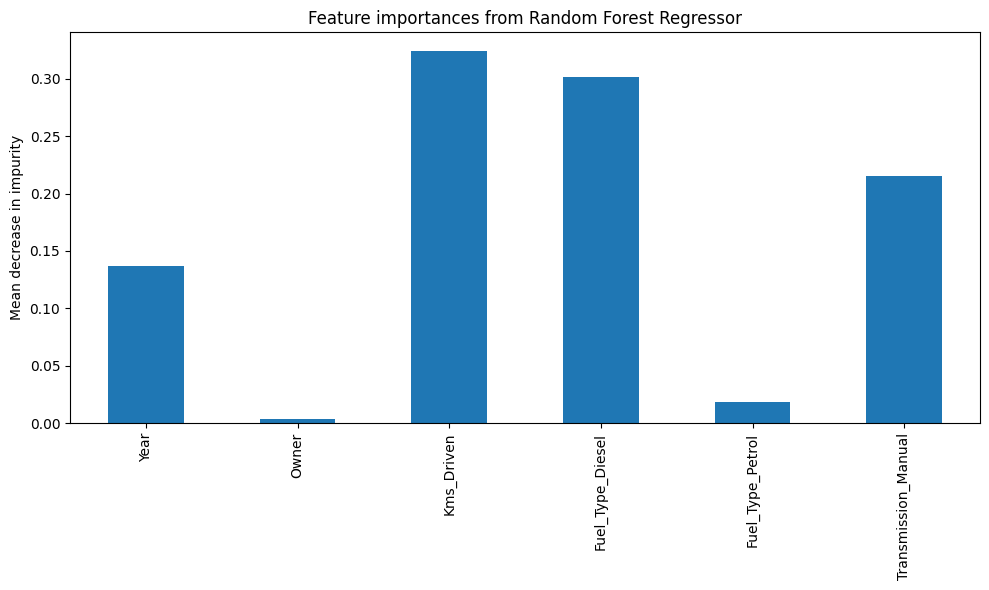

In [131]:
# from the output random forest regressor is the best model for car price prediction
best_model = models["Random Forest Regressor"]
importances = best_model.feature_importances_
feature_names = x_train.columns

#identifying the feature importance for the model

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances from Random Forest Regressor")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

In [133]:
def predict_resale_value(model, car_features):
    car_df = pd.DataFrame([car_features])
    car_df = pd.get_dummies(car_df, drop_first=True)

    aligned_car_df = pd.DataFrame(columns=x_train.columns)
    aligned_car_df = pd.concat([aligned_car_df, car_df], ignore_index=True)
    aligned_car_df = aligned_car_df.fillna(0)

    prediction = model.predict(aligned_car_df)
    return prediction[0]

year = int(input("Enter the year of manufacture: "))
kms_driven = int(input("Enter the kilometers driven: "))
fuel_type = input("Enter fuel type (Petrol/Diesel/CNG): ")
transmission = input("Enter transmission type (Manual/Automatic): ")
owner = int(input("Enter number of previous owners: "))

car_details = {
    "Year": year,
    "Kms_Driven": kms_driven,
    "Fuel_Type": fuel_type,
    "Transmission": transmission,
    "Owner": owner
}
print("Car details entered:", car_details)


predicted_value = predict_resale_value(best_model, car_details)
print(f"Predicted Resale Value for a sample car: {predicted_value:.2f} lakhs")


Enter the year of manufacture: 2002
Enter the kilometers driven: 2345
Enter fuel type (Petrol/Diesel/CNG): Petrol
Enter transmission type (Manual/Automatic): Manual
Enter number of previous owners: 2
Car details entered: {'Year': 2002, 'Kms_Driven': 2345, 'Fuel_Type': 'Petrol', 'Transmission': 'Manual', 'Owner': 2}
Predicted Resale Value for a sample car: 2.00 lakhs


/tmp/ipykernel_610/2402817461.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aligned_car_df = aligned_car_df.fillna(0)


In [135]:
import joblib
joblib.dump(x_train.columns, 'model_columns.pkl')

['model_columns.pkl']